In [38]:
import os
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# FOR ONE PATIENT
df = pd.read_csv(r"D:\DATA_Myelomy\Myel_001\BMD_radiomics_individual_lesion_features.csv")
df = df.filter(like="shape")  # dataframe with just shape features

shape_features_stats = {}
for col in df.columns:
    x = df[col]

    shape_features_stats[f"{col}_mean"]   = x.mean()
    shape_features_stats[f"{col}_median"] = x.median()
    shape_features_stats[f"{col}_std"]    = x.std()
    shape_features_stats[f"{col}_var"]    = x.var()
    shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
    shape_features_stats[f"{col}_range"]  = x.max() - x.min()
    shape_features_stats[f"{col}_min"]    = x.min()
    shape_features_stats[f"{col}_max"]    = x.max()

df_shape_features_stats = pd.DataFrame([shape_features_stats])
df_shape_features_stats

,original_shape_Elongation_mean,original_shape_Elongation_median,original_shape_Elongation_std,original_shape_Elongation_var,original_shape_Elongation_cv,original_shape_Elongation_range,original_shape_Elongation_min,original_shape_Elongation_max,original_shape_Flatness_mean,original_shape_Flatness_median,...,original_shape_SurfaceVolumeRatio_min,original_shape_SurfaceVolumeRatio_max,original_shape_VoxelVolume_mean,original_shape_VoxelVolume_median,original_shape_VoxelVolume_std,original_shape_VoxelVolume_var,original_shape_VoxelVolume_cv,original_shape_VoxelVolume_range,original_shape_VoxelVolume_min,original_shape_VoxelVolume_max
0,0.689997,0.760516,0.18199,0.03312,0.263755,0.618176,0.36476,0.982936,0.559757,0.612309,...,1.054741,2.324836,90.066468,67.007816,72.048213,5190.944967,0.799945,418.655669,21.763222,440.418892


In [17]:
# FOR ALL PATIENTS
main_folder_path = r"D:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col]

        shape_features_stats[f"{col}_mean"]   = x.mean()
        shape_features_stats[f"{col}_median"] = x.median()
        shape_features_stats[f"{col}_std"]    = x.std()
        shape_features_stats[f"{col}_var"]    = x.var()
        shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
        shape_features_stats[f"{col}_range"]  = x.max() - x.min()
        shape_features_stats[f"{col}_min"]    = x.min()
        shape_features_stats[f"{col}_max"]    = x.max()

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)
df_final

,patient_id,original_shape_Elongation_mean,original_shape_Elongation_median,original_shape_Elongation_std,original_shape_Elongation_var,original_shape_Elongation_cv,original_shape_Elongation_range,original_shape_Elongation_min,original_shape_Elongation_max,original_shape_Flatness_mean,...,original_shape_SurfaceVolumeRatio_min,original_shape_SurfaceVolumeRatio_max,original_shape_VoxelVolume_mean,original_shape_VoxelVolume_median,original_shape_VoxelVolume_std,original_shape_VoxelVolume_var,original_shape_VoxelVolume_cv,original_shape_VoxelVolume_range,original_shape_VoxelVolume_min,original_shape_VoxelVolume_max
0,Myel_001,0.689997,0.760516,0.181990,0.033120,0.263755,0.618176,0.364760,0.982936,0.559757,...,1.054741,2.324836,90.066468,67.007816,72.048213,5.190945e+03,0.799945,418.655669,21.763222,440.418892
1,Myel_002,0.648647,0.653383,0.169330,0.028673,0.261051,0.515505,0.369943,0.885448,0.454540,...,0.841262,1.746274,366.622703,239.994455,340.455556,1.159100e+05,0.928626,1220.019545,45.249551,1265.269096
2,Myel_003,0.711343,0.771383,0.192809,0.037175,0.271050,0.554634,0.333845,0.888479,0.576488,...,1.120211,1.623717,143.621552,95.604581,137.102243,1.879703e+04,0.954608,415.049827,52.095909,467.145736
3,Myel_004,0.695205,0.713297,0.129638,0.016806,0.186475,0.631247,0.343554,0.974801,0.508115,...,0.633748,4.476636,552.265578,175.129278,1397.165564,1.952072e+06,2.529880,9692.203662,5.150861,9697.354523
4,Myel_005,0.696425,0.696445,0.104387,0.010897,0.149890,0.327024,0.546637,0.873662,0.535343,...,0.784054,1.734693,283.266818,175.981890,310.137679,9.618538e+04,1.094861,980.099729,45.682614,1025.782343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Myel_077,0.647038,0.678280,0.143430,0.020572,0.221672,0.616463,0.284103,0.900566,0.441154,...,0.644811,5.488186,306.286208,103.305095,542.142336,2.939183e+05,1.770051,3040.775446,4.578619,3045.354065
68,Myel_078,0.646723,0.677827,0.173979,0.030269,0.269017,0.710326,0.227829,0.938156,0.435600,...,0.797936,5.919622,822.970178,109.329732,1738.383593,3.021978e+06,2.112329,8154.509768,5.724070,8160.233838
69,Myel_079,0.702984,0.696841,0.133507,0.017824,0.189914,0.445429,0.487462,0.932891,0.500648,...,0.727774,6.511439,171.004716,64.521916,238.960278,5.710201e+04,1.397390,993.231069,4.064373,997.295442
70,Myel_080,0.644901,0.611859,0.157034,0.024660,0.243501,0.651276,0.348724,1.000000,0.456768,...,0.413366,3.592244,1389.968483,254.106927,2493.733438,6.218706e+06,1.794094,10522.544966,4.578503,10527.123470


In [37]:
# KRUSKAL-WALLIS TEST BETWEEN STAGE GROUPS AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID', how='inner')

results = []
for feature in numeric_features:

    # data = pd.concat([df_final[feature], clinical_df['Stage']], axis=1).dropna()
    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    from scipy.stats import kruskal
    stat, p_value = kruskal(stage1, stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head(10)

,Feature,H_all,p_value
8,original_shape_Flatness_mean,14.265137,0.000799
9,original_shape_Flatness_median,13.100096,0.001430
1,original_shape_Elongation_median,11.588060,0.003046
0,original_shape_Elongation_mean,11.188244,0.003720
4,original_shape_Elongation_cv,6.592925,0.037014
17,original_shape_LeastAxisLength_median,5.875030,0.052997
65,original_shape_MeshVolume_median,5.757224,0.056213
105,original_shape_VoxelVolume_median,5.433698,0.066083
96,original_shape_SurfaceVolumeRatio_mean,5.263192,0.071964
3,original_shape_Elongation_var,4.900185,0.086286


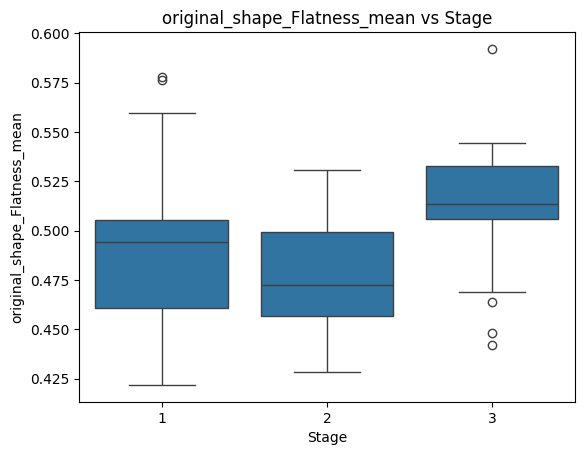

In [44]:
img_feature = "original_shape_Flatness_mean"

sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage', fontsize=12)
plt.show()